<a href="https://colab.research.google.com/github/usamarehman394/Forecasting-Project-/blob/main/Forecasting_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Github Repository Link:
https://github.com/yourfavkomal/Forecasting-Project-


# Group Project: Food Demand Forecasting
**Group Members:**  BADR KOURDAD
                    KOMAL SOHAIL
                    USAMA REHMAN
                    JANIL BHATASANA

The primary goal of this Google Colab is Demand Forecasting and Optimization.

Our dataset will help us to assess historical demand for various meal-center combinations so that the food delivery service can predict future orders. This helps in inventory management, reducing food wastage, and optimizing logistics. Moreover,

## 1. Problem Definition
The purpose of this project is to estimate the future food demand by predicting the number of orders for different meals across multiple delivery centers. In the food delivery industry, knowing customer demand in advance is essential for smooth daily operations and better service management.

Without proper forecasting, companies may either prepare too much food, which leads to wastage, or prepare too little, which can cause delays and customer dissatisfaction. To overcome these challenges, this project uses previous order records to study customer ordering patterns and trends.

The system applies data analysis and machine learning methods to generate accurate demand predictions. These predictions can support better decision-making in areas such as food preparation, stock management, and delivery planning. As a result, the project can help improve operational efficiency, reduce unnecessary costs, minimize food waste, and enhance customer satisfaction.

**Target Variable:** `num_orders`

**Forecasting Horizon:** 10 weeks

In [ ]:
import pandas as pd
import matplotlib as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fulfilment_center_info.csv to fulfilment_center_info.csv
Saving meal_info.csv to meal_info.csv
Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


I have used google collab import to import my files.

In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


Thwn I made sure that I was able to see my dataset clearly and how many rows and columns were there.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


## 2. Data Preparation and Merging
To perform a comprehensive Exploratory Data Analysis (EDA) and understand the drivers of demand, we must look beyond the target variable. We merge the main transactional dataset (`train.csv`) with auxiliary information about the meals (`meal_info.csv`) and the fulfillment centers (`fulfilment_center_info.csv`). This combined dataset will allow us to analyze demand by cuisine type, promotions, and center characteristics.

In [ ]:
# --- ADDED BY BADR: Merging Datasets for deeper EDA ---

# Load the auxiliary datasets
meal_info_df = pd.read_csv('meal_info.csv')
center_info_df = pd.read_csv('fulfilment_center_info.csv')

# Merge the main train dataset ('df') with meal and center info
df_merged = df.merge(meal_info_df, on='meal_id', how='left')
df_merged = df_merged.merge(center_info_df, on='center_id', how='left')

# Display the first few rows to verify the new columns (category, cuisine, center_type)
df_merged.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


In [ ]:
weekly_data = df.groupby("week")["num_orders"].sum().reset_index()
weekly_data.head()

,week,num_orders
0,1,792261
1,2,787084
2,3,695262
3,4,743529
4,5,1198675


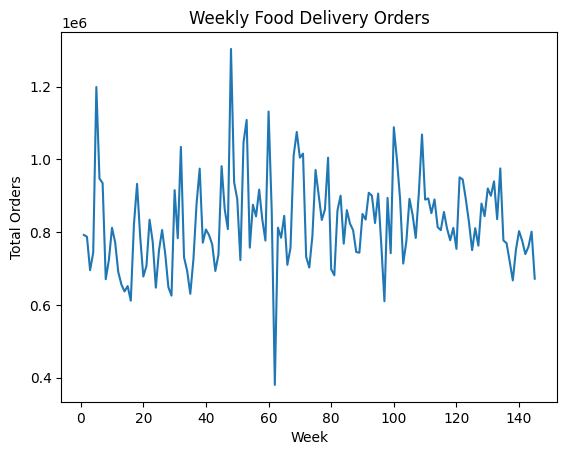

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(weekly_data["week"], weekly_data["num_orders"])
plt.xlabel("Week")
plt.ylabel("Total Orders")
plt.title("Weekly Food Delivery Orders")
plt.show()

The graph shows the total number of weekly food delivery orders over time. The demand fluctuates significantly between approximately 600,000 and 1.3 million orders, indicating high variability in customer behavior. There are several noticeable peaks, particularly around the mid-period (around weeks 40–60), where demand reaches its highest levels. There is also a decrease near 60 week where orders where the lowest and maybe it can be due to price changes, lack of promotions.

**EDA Insight: Overall Demand Trend**
The time series visualization of the aggregated weekly demand reveals a highly volatile pattern with significant, sudden spikes rather than a smooth, predictable trend. This high variance suggests that external business factors (such as marketing campaigns or holidays) strongly disrupt the baseline demand.

/tmp/ipykernel_1419/1740924304.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='emailer_for_promotion', y='num_orders', data=promo_impact, palette='viridis')


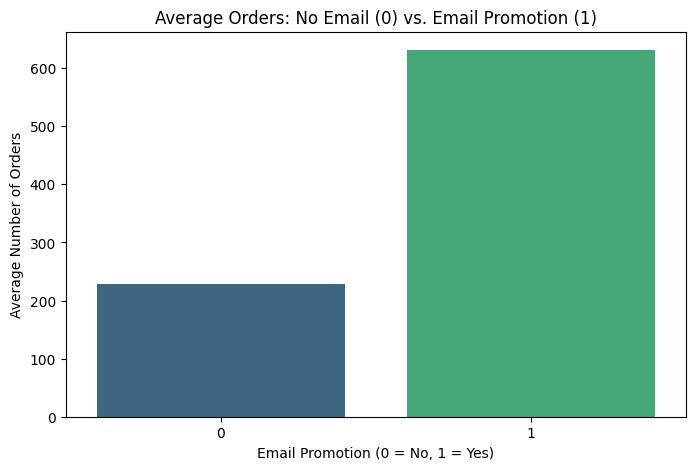

In [ ]:
# --- ADDED BY BADR: EDA - Impact of Email Promotions ---

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# Calculate average orders with and without email promotion
promo_impact = df_merged.groupby('emailer_for_promotion')['num_orders'].mean().reset_index()

sns.barplot(x='emailer_for_promotion', y='num_orders', data=promo_impact, palette='viridis')
plt.title('Average Orders: No Email (0) vs. Email Promotion (1)')
plt.xlabel('Email Promotion (0 = No, 1 = Yes)')
plt.ylabel('Average Number of Orders')
plt.show()

**EDA Insight: The Impact of Marketing Campaigns**
This bar chart clearly demonstrates a massive disparity in average orders when an email promotion is active. The demand effectively triples during promotional weeks. This is a critical insight for our modeling phase: pure auto-regressive models (like basic ARIMA) might struggle to predict these extreme spikes without including `emailer_for_promotion` as an exogenous variable.

In [ ]:
weekly_data.isnull().sum()

,0
week,0
num_orders,0


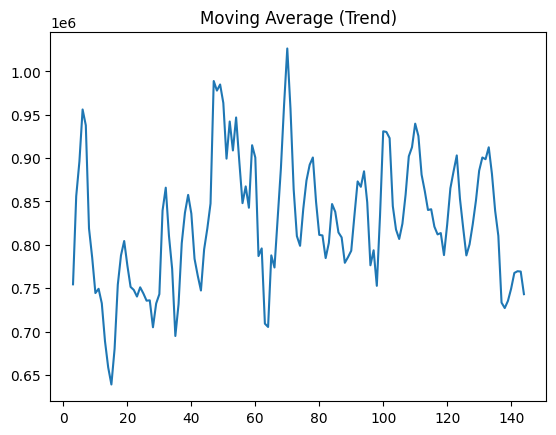

In [ ]:
weekly_data["num_orders"].rolling(window=4).mean().plot()
plt.title("Moving Average (Trend)")
plt.show()

In [ ]:
train_size = int(len(weekly_data) * 0.8)

train = weekly_data[:train_size]
test = weekly_data[train_size:]

In [ ]:
print("Min week:", weekly_data["week"].min())
print("Max week:", weekly_data["week"].max())

Min week: 1
Max week: 145


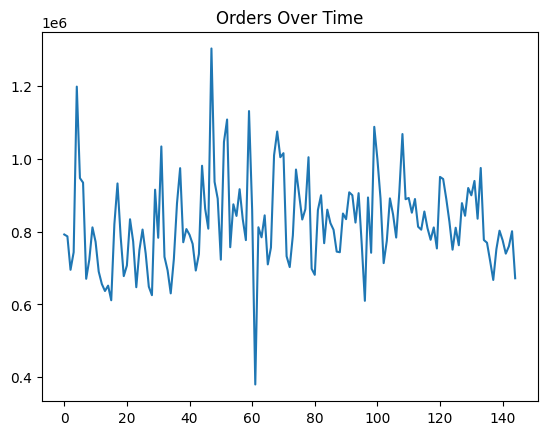

In [ ]:
weekly_data["num_orders"].plot()
plt.title("Orders Over Time")
plt.show()

This graph shows an average of order volumns of over 144 weeks, highlighting the monthly pattern. the gragh doesnt have neccessary peaks going upwards and downwards this means that the overall performance of the busines is stationary—it reveals significant volatility with orders fluctuating between a low of roughly 640,000 near week 15 and a major peak of over 1 million around week 70. the continous peak shows a strong seasonal cycle as the data keeps going back to baseline of roughly 825,000 orders after every spike.

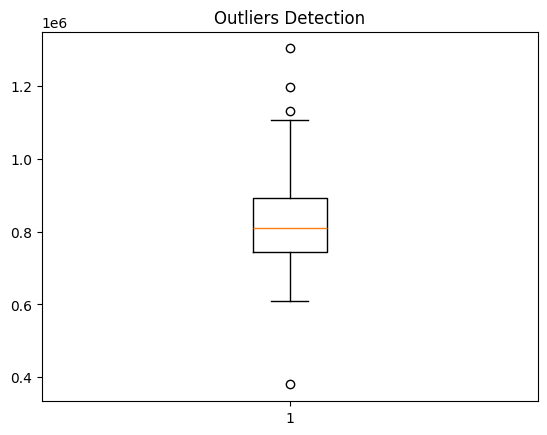

In [ ]:
plt.figure()
plt.boxplot(weekly_data["num_orders"])
plt.title("Outliers Detection")
plt.show()

This boxplot provides a statistical summary of your weekly order distribution, specifically highlighting several significant outliers that fall outside the expected range. The box plot represents the 50% of your weekly orders that are approximately 750,000 and 900,000, with the median volume (the orange line) sitting around 810,000.
The plot identifies four extreme data points that divert from this which is the one unusually low week dipping to roughly 380,000 and three high-performing weeks that are in the upper region and the highest peak reaching approximately 1.3 million. These outliers represent some kind of operational issues, logistic failure.

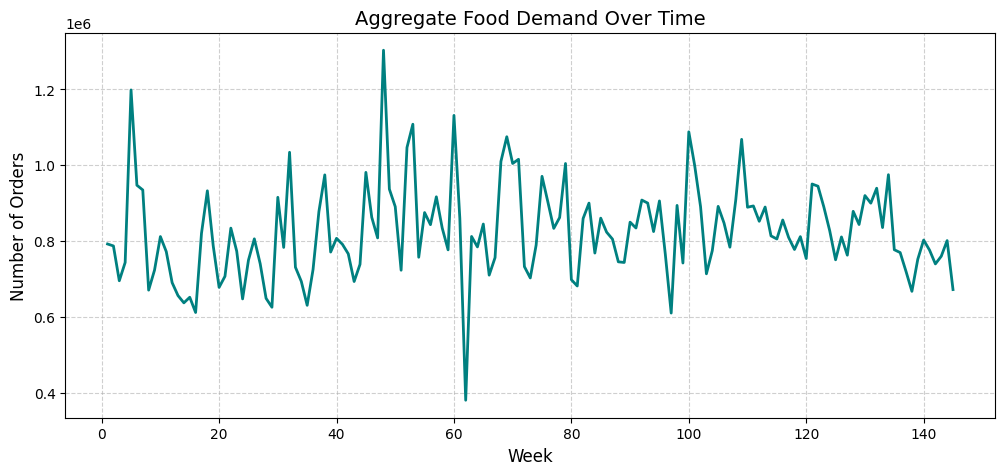

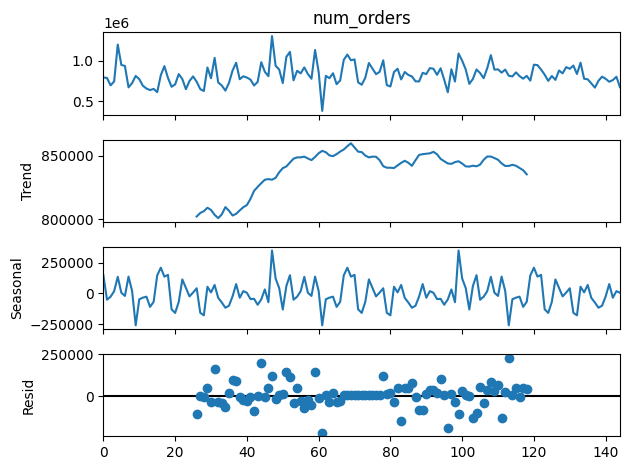

--- ADF Test Results ---
ADF Statistic: -2.5429
p-value: 0.1054

Training on weeks: 1 to 116
Validating on weeks: 117 to 145


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. Load your datasets using exact filenames
train = pd.read_csv("train.csv")
meal_info = pd.read_csv("meal_info.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

# 2. Collaborative Work: Exploratory Data Analysis (EDA)
# Merge train and meal_info to get categorical details for each order
df = pd.merge(train, meal_info, on="meal_id", how="left")

# Aggregate by week to see the overall network demand
weekly_data = df.groupby("week")["num_orders"].sum().reset_index()

# Visualization: Total Weekly Demand
plt.figure(figsize=(12, 5))
plt.plot(weekly_data["week"], weekly_data["num_orders"], color='teal', linewidth=2)
plt.title("Aggregate Food Demand Over Time", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Seasonal Decomposition (Identifying Patterns)
# Period=52 because it's weekly data spanning nearly 3 years
result = seasonal_decompose(weekly_data["num_orders"], model='additive', period=52)
result.plot()
plt.show()

# 4. Statistical Test: Augmented Dickey-Fuller (ADF)
# This is crucial for justifying your model choice (Stationarity)
print("--- ADF Test Results ---")
adf_test = adfuller(weekly_data["num_orders"])
print(f"ADF Statistic: {adf_test[0]:.4f}")
print(f"p-value: {adf_test[1]:.4f}")
# If p-value < 0.05, the data is stationary.

# 5. Individual Work: Validation Strategy
# Splitting the aggregated data for evaluation
train_size = int(len(weekly_data) * 0.8)
train_set = weekly_data[:train_size]
val_set = weekly_data[train_size:]

print(f"\nTraining on weeks: {train_set['week'].min()} to {train_set['week'].max()}")
print(f"Validating on weeks: {val_set['week'].min()} to {val_set['week'].max()}")

This gragh actually shows the demand data assessed by Augmented Dickey-Fuller (ADF) test, with a p-value of 0.1054. Since this is more than 0.05 significance , the null hypothesis cannot be rejected, confirming that the series is non-stationary and possesses time-dependent structures that require transformation before modeling.
To assess that how accurate the models are for the future prediction the data should be partitioned chronologically rather than randomly; the first 115 weeks serve as the training foundation, while the final 20% (weeks 116 to 145) are reserved for out-of-sample validation to simulate real-world forecasting performance.

**EDA Insight: Stationarity Check**
The Augmented Dickey-Fuller (ADF) test yields a p-value of ~0.105, which is greater than the standard 0.05 threshold. This indicates that our time series is **not strictly stationary**. For group members planning to use classical statistical models like ARIMA, differencing (setting the 'd' parameter to 1) will be a necessary preprocessing step.

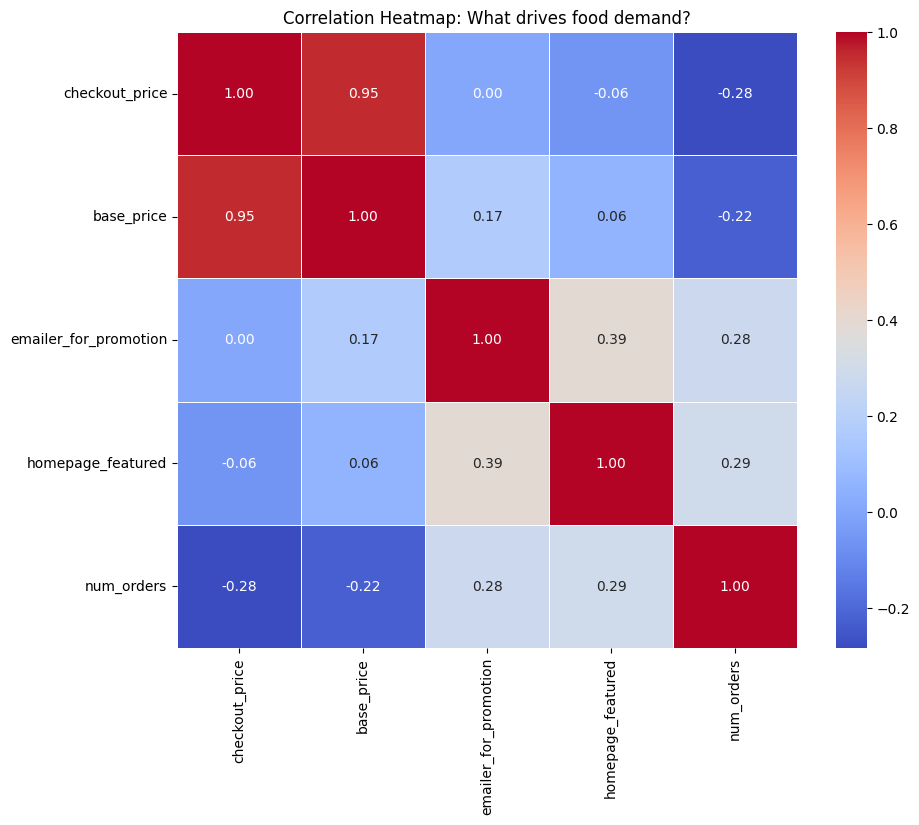

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
train = pd.read_csv("train.csv")

# 2. Select numerical columns that actually impact demand
# checkout_price: price customer pays
# base_price: original price
# emailer_for_promotion & homepage_featured: binary markers (0 or 1)
# num_orders: our TARGET variable
corr_cols = ['checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders']
correlation_matrix = train[corr_cols].corr()

# 3. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: What drives food demand?")
plt.show()

**EDA Insight: Feature Correlation**
The correlation heatmap confirms our previous findings. Both `emailer_for_promotion` and `homepage_featured` show a positive correlation with our target variable `num_orders`. Conversely, `checkout_price` has a negative correlation, confirming the basic economic principle that higher prices tend to lower demand.

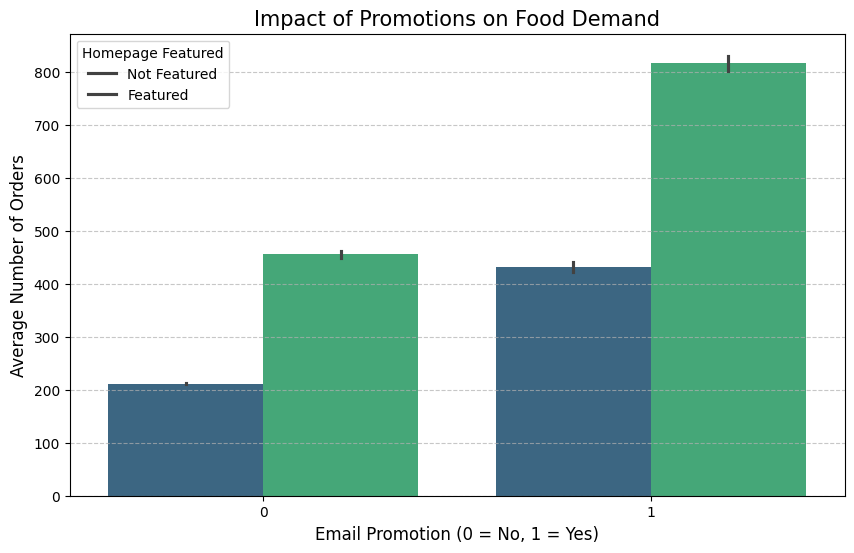

Average Orders Summary Table:
homepage_featured               0           1
emailer_for_promotion                        
0                      211.416983  455.876208
1                      431.277625  816.246061


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('train.csv')

# 2. Calculate average orders based on promotion status
# This creates a summary of how effective each marketing channel is
promo_summary = df.groupby(['emailer_for_promotion', 'homepage_featured'])['num_orders'].mean().reset_index()

# 3. Create the Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='emailer_for_promotion', y='num_orders', hue='homepage_featured', palette='viridis')

# Adding labels and title for clarity
plt.title('Impact of Promotions on Food Demand', fontsize=15)
plt.xlabel('Email Promotion (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Average Number of Orders', fontsize=12)
plt.legend(title='Homepage Featured', labels=['Not Featured', 'Featured'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# 4. Display the raw numbers for precise reference
print("Average Orders Summary Table:")
print(promo_summary.pivot(index='emailer_for_promotion', columns='homepage_featured', values='num_orders'))

In [ ]:
# Assuming you already have 'df' as your train.csv
meal_info = pd.read_csv("meal_info.csv")

# Merge train data with meal info
df = pd.merge(df, meal_info, on="meal_id", how="left")

# Check the new structure
print(df.head())

        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders   category cuisine  
0                      0                  0         177  Beverages    Thai  
1                      0                  0         270  Beverages    Thai  
2                      0                  0         189  Beverages    Thai  
3                      0                  0          54  Beverages  Indian  
4                      0                  0          40  Beverages  Indian  


In [ ]:
# Sort by week to ensure chronological order
df = df.sort_values(['center_id', 'meal_id', 'week'])

# Create a lag feature: Total orders from the previous week for that specific center/meal
df['prev_week_orders'] = df.groupby(['center_id', 'meal_id'])['num_orders'].shift(1)

# Calculate the discount offered
df['discount'] = df['base_price'] - df['checkout_price']

## 4. Agreed Validation and Evaluation Strategy

**Validation Strategy (Data Splitting):**
Since we are dealing with time-series data, random splitting (like standard `train_test_split`) is not appropriate because it causes data leakage from the future into the past. We must use a **Time-Based (Chronological) Split**. We will use the first 130 weeks as our Training Set and the remaining weeks (131 to 145) as our Validation (Test) Set.

**Evaluation Metrics:**
To objectively compare the different forecasting models developed individually by group members, we agree to evaluate performance using:
- **MAE (Mean Absolute Error):** To understand the average magnitude of our forecasting errors in real order quantities.
- **RMSE (Root Mean Squared Error):** To heavily penalize the large errors that occur during the sudden demand spikes we identified in our EDA.

*Each group member will now proceed to implement and tune a distinct forecasting model in their individual notebooks.*

In [ ]:
# --- ADDED BY BADR: Time-Based Train/Test Split ---

# Define the split point (Week 130)
split_week = 130

# Split the dataset chronologically
train_set = df[df['week'] <= split_week]
val_set = df[df['week'] > split_week]

print("--- Validation Strategy ---")
print(f"Training data: Weeks {train_set['week'].min()} to {train_set['week'].max()} ({len(train_set)} records)")
print(f"Validation data: Weeks {val_set['week'].min()} to {val_set['week'].max()} ({len(val_set)} records)")

--- Validation Strategy ---
Training data: Weeks 1 to 130 (407243 records)
Validation data: Weeks 131 to 145 (49305 records)
